In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
import pandas as pd
from pybib.calc import *
import os
!pip freeze > requirements.txt

# 1. Analise dos dados

## Political Blogs

In [2]:
file_path = './polblogs/polblogs.gml'
G = load_gml(file_path)
G = apagar_nos_com_grau_zero(G)

In [53]:
categorias = np.array([G.nodes[i]['weight'] for i in G.nodes])

In [44]:
value_in = np.zeros((len(G.nodes),2))
value_out = np.zeros((len(G.nodes),2))

# Iterar sobre os nós e contar as categorias das arestas de entrada
for node in G.nodes:
    for pred in G.predecessors(node):
        value_in[node][int( G.nodes[pred]['weight'])] +=1 
    for pred in G.successors(node):
        value_out[node][int( G.nodes[pred]['weight'])] +=1 
    
print(value_out)

print(value_in)

[[ 1.  2.]
 [ 4. 20.]
 [ 7.  3.]
 ...
 [ 0.  2.]
 [ 7.  1.]
 [ 2.  7.]]
[[ 1.  0.]
 [ 1.  5.]
 [97. 20.]
 ...
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]]


In [54]:
np.savetxt('./input/test/out.txt',value_out[np.argsort(np.sum(value_out,axis = 1))[::-1]],fmt = '%d %d')
np.savetxt('./input/test/in.txt',value_in[np.argsort(np.sum(value_out,axis = 1))[::-1]],fmt = '%d %d')
np.savetxt('./input/test/faixas.txt',categorias[np.argsort(np.sum(value_out,axis = 1))],fmt = '%d')

In [34]:
np.sum(value_out)

np.float64(0.0)

In [29]:
G = nx.relabel_nodes(G, {i[1]:i[0] for i in enumerate(G.nodes)})

In [12]:
G[pred][node]

{}

In [5]:
categorias

array([0, 1, 0, ..., 1, 0, 1])

In [9]:
w = np.unique(categorias,return_counts=True)[1]
w = w/np.sum(w)
np.savetxt('./input/polblogs/faixas.txt',w,fmt = '%f')

In [37]:
nx.attribute_assortativity_coefficient(G,'weight')

0.8229242280560486

In [6]:
plt.figure(figsize=(10, 8))
Matrix = generate_distribution_byfaixas(df_out,categorias)

heatmap = sns.heatmap(Matrix, 
                      annot=True,          # Adiciona os valores em cada célula
                      fmt=".2f",           # Formato dos números exibidos
                      cmap="coolwarm",      # Paleta de cores que vai do azul ao vermelho
                      #cbar_kws={'label': 'Escala de valores'},  # Legenda da barra de cores
                      linewidths=0.5,       # Largura das linhas entre as células
                      linecolor='gray')     # Cor das linhas

# Título e rótulos
plt.xlabel("Variável X")
plt.ylabel("Variável Y")

# Ajustes finais
plt.tight_layout()
plt.title("Matrix de Saída")
#np.savetxt('./input/multi_probability_out.txt',Matrix,fmt = '%f')
# Exibir o gráfico
plt.show()

NameError: name 'df_out' is not defined

<Figure size 1000x800 with 0 Axes>

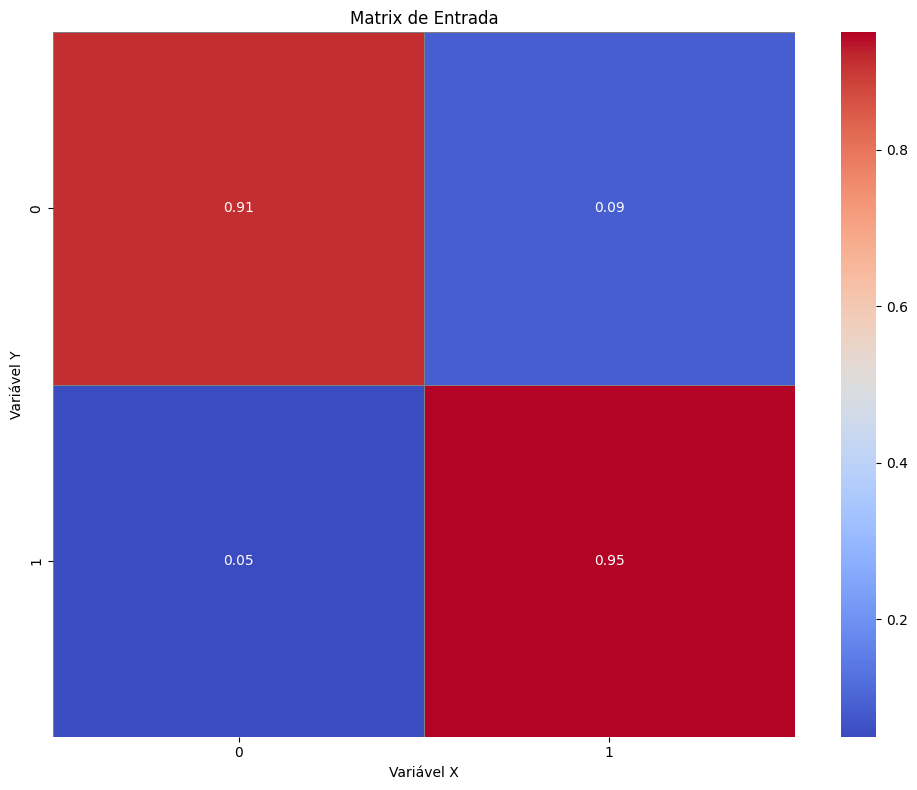

In [14]:
plt.figure(figsize=(10, 8))
Matrix = generate_distribution_byfaixas(df_in,categorias)
heatmap = sns.heatmap(Matrix, 
                      annot=True,          # Adiciona os valores em cada célula
                      fmt=".2f",           # Formato dos números exibidos
                      cmap="coolwarm",      # Paleta de cores que vai do azul ao vermelho
                      #cbar_kws={'label': 'Escala de valores'},  # Legenda da barra de cores
                      linewidths=0.5,       # Largura das linhas entre as células
                      linecolor='gray')     # Cor das linhas

# Título e rótulos
plt.xlabel("Variável X")
plt.ylabel("Variável Y")

# Ajustes finais
# É mais provável dado um espectro político citar o outro espectro do que o outro espectro citar você.
plt.title("Matrix de Entrada")
plt.tight_layout()
np.savetxt('./input/multi_probability_in.txt',Matrix,fmt = '%f')
# Exibir o gráfico
plt.show()

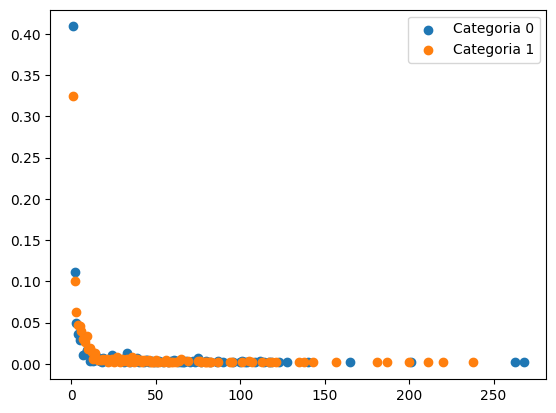

In [3]:
gin,gout = calcular_graus_por_categoria(G,0)
arr,hist = histogram(gin)
plt.scatter(arr,hist/np.sum(hist),label = 'Categoria 0')
gin,gout = calcular_graus_por_categoria(G,1)
arr,hist = histogram(gin)
plt.scatter(arr,hist/np.sum(hist),label = 'Categoria 1')
#arr,hist = histogram(gout)
#plt.scatter(arr,hist,label = 'Degree out')
plt.legend()
plt.show()

In [5]:
def generate_distribuition(G,categoria):
    gin,gout = calcular_graus_por_categoria(G,categoria)
    gin,p = histogram(gin)
    p = p/np.sum(p)
    m = 268

    arr = np.arange(m+1)
    prob = np.ones(len(arr))*-1
    p = np.cumsum(p)
    for i,p in zip(gin,p):
        prob[i-1] = p
    P = np.array([arr,prob]).T

    np.savetxt(f'./input/distribution_{categoria}_in.txt',P,fmt = "%d %f")
    gout,p = histogram(gout)
    p = p/np.sum(p)
    arr = np.arange(m+1)
    prob = np.ones(len(arr))*-1
    p = np.cumsum(p)
    for i,p in zip(gout,p):
        prob[i-1] = p
    P = np.array([arr,prob]).T

    np.savetxt(f'./input/distribution_{categoria}_out.txt',P,fmt = "%d %f")

In [6]:
generate_distribuition(G,0)
generate_distribuition(G,1)

## Comes F

In [7]:
comes_f = pd.read_excel('./input/RawData_ComesF.xlsx',header =2)
comes_f = comes_f.loc[:, ~comes_f.columns.str.contains('lieux')]
comes_f.columns = [col.lower() for col in comes_f.columns]
comes_f = comes_f.loc[:, comes_f.columns.str.contains('age')]
comes_f = comes_f.loc[:, ~comes_f.columns.str.contains('personne')]
comes_f = comes_f.loc[:, ~comes_f.columns.str.contains('min')]
comes_f = comes_f.loc[:, ~comes_f.columns.str.contains('max')]
comes_f = comes_f.loc[:, ~comes_f.columns.str.contains("l'enfant")]

In [8]:
comes_f_day_1 = comes_f[comes_f.columns[1:41]]
comes_f_day_2 = comes_f[comes_f.columns[41:]]

In [10]:
contatos = {}
contatos1 = {}
contatos2 = {}
idade = comes_f['age du sujet de l\'enquête'].values
for index, row in comes_f_day_1.iterrows():
    valores_ate_nan = row[:row.isna().idxmax()].tolist() 
    contatos1[index] = np.array(valores_ate_nan)[:-1].tolist()

for index, row in comes_f_day_2.iterrows():
    valores_ate_nan = row[:row.isna().idxmax()].tolist() 
    contatos2[index] = np.array(valores_ate_nan)[:-1].tolist()
for i in contatos1:
    contatos[i] = contatos1[i]+contatos2[i]
print(contatos)

{0: [68.0, 55.0, 68.0], 1: [29.0, 33.0, 3.0, 41.0, 13.0, 18.0, 29.0, 33.0, 3.0, 8.0], 2: [49.0, 48.0, 16.0, 57.0, 22.0, 47.0, 28.0, 29.0, 6.0, 32.0, 50.0, 49.0, 48.0, 16.0, 6.0, 52.0, 52.0, 22.0, 22.0, 52.0, 28.0], 3: [81.0, 75.0, 69.0, 42.0, 74.0, 76.0, 81.0], 4: [73.0, 45.0, 55.0, 73.0, 32.0], 5: [65.0, 12.0, 10.0, 8.0, 44.0, 42.0, 37.0, 65.0, 12.0, 10.0, 8.0], 6: [76.0, 74.0, 48.0, 50.0, 36.0, 34.0, 10.0, 8.0, 1.0, 56.0, 35.0, 4.0, 77.0, 36.0, 34.0, 10.0, 8.0, 1.0], 7: [48.0, 16.0, 19.0, 18.0, 25.0, 18.0, 32.0, 21.0, 48.0, 50.0, 16.0, 18.0, 18.0, 18.0, 19.0, 18.0, 18.0, 18.0, 18.0], 8: [43.0, 15.0, 13.0, 64.0, 64.0, 10.0, 6.0, 41.0, 55.0], 9: [65.0, 67.0, 54.0, 41.0, 15.0, 11.0, 43.0, 72.0, 45.0, 19.0, 14.0, 38.0, 43.0, 71.0], 10: [35.0, 55.0, 62.0, 71.0, 40.0, 45.0, 52.0, 62.0, 62.0, 55.0, 53.0, 48.0, 47.0, 50.0, 62.0, 50.0, 44.0, 56.0, 50.0], 11: [52.0, 42.0], 12: [32.0, 32.0, 73.0, 30.0, 30.0, 3.0, 30.0, 73.0, 50.0, 40.0, 30.0], 13: [21.0, 30.0, 70.0, 60.0, 65.0, 19.0, 72.0, 58.0

In [76]:
idade

array([38,  0, 18, ..., 22,  0,  4])

In [11]:

def get_faixa(idade):
    faixas = np.array([ 20,30,50,70,1e8])
    indices = np.searchsorted(faixas,idade,side='right')
    indices= np.where(indices < len(faixas),indices,None)
    return indices

In [12]:
idade = get_faixa(idade)
Contatos = np.zeros((len(contatos),5))
for i in contatos:
    valores = get_faixa(np.array(contatos[i]))
    for j in valores:
        Contatos[i][j] += 1

In [80]:
idade

array([2, 0, 0, ..., 1, 0, 0], dtype=object)

In [82]:
test = []
for i in contatos.values():
    test += i
test = get_faixa(test)
test = np.unique(test,return_counts=True)[1]
test = test/np.sum(test)
np.savetxt(f'./input/ComesF/faixas.txt',test, fmt = "%f")

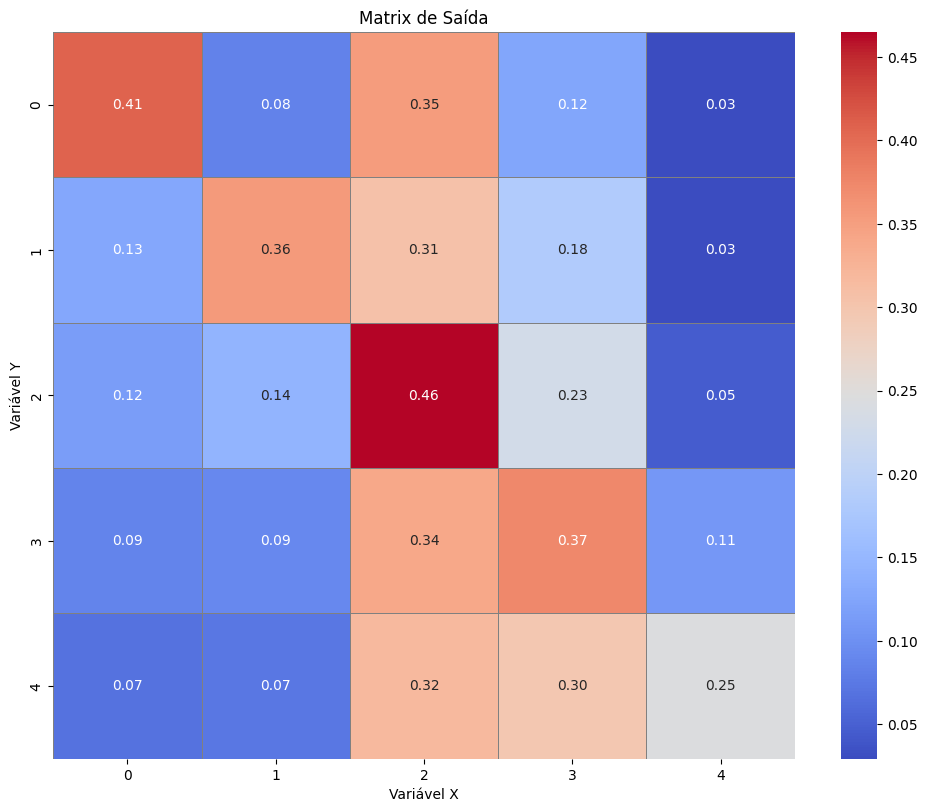

In [33]:
plt.figure(figsize=(10, 8))
Matrix = generate_distribution_byfaixas(Contatos,idade)

heatmap = sns.heatmap(Matrix, 
                      annot=True,          # Adiciona os valores em cada célula
                      fmt=".2f",           # Formato dos números exibidos
                      cmap="coolwarm",      # Paleta de cores que vai do azul ao vermelho
                      #cbar_kws={'label': 'Escala de valores'},  # Legenda da barra de cores
                      linewidths=0.5,       # Largura das linhas entre as células
                      linecolor='gray')     # Cor das linhas

# Título e rótulos
plt.xlabel("Variável X")
plt.ylabel("Variável Y")

# Ajustes finais
plt.tight_layout()
plt.title("Matrix de Saída")
np.savetxt('./input/ComesF/multi_probability_out.txt',Matrix,fmt = '%f')
# Exibir o gráfico
plt.show()

In [32]:
N = np.max(np.sum(Contatos,axis = 1)).astype(int)
arr = np.arange(1,N+1)
for f in range(5):
    hist = np.zeros(len(arr))
    graus = np.sum(Contatos[idade == f],axis = 1)
    graus = graus[graus > 0].astype(int)
    for i in graus:
        hist[i-1] += 1
    h= np.copy(hist)
    hist = hist/np.sum(hist)
    hist = np.cumsum(hist)
    hist[h == 0] = -1
    np.savetxt(f'./input/ComesF/distribution_{f}_out.txt',np.array([arr,hist]).T,fmt = "%d %f")

In [67]:
idade = np.unique(idade,return_counts=True)[1]
print(idade)
idade = idade/np.sum(idade)
np.savetxt(f'./input/ComesF/faixas.txt',idade, fmt = "%f")

[858 169 231 549 226]


# 2. Análise do modelo

In [5]:
def process_files_to_dataframe(directory):
    # Prepare an empty list to store the data
    data = []
    
    # Iterate through files in the directory
    for file_name in os.listdir(directory):
        if file_name.startswith("resultados_") and file_name.endswith(".txt"):
            # Extract components from the file name
            parts = file_name.replace("resultados_", "").replace(".txt", "").split("_")
            if len(parts) == 3:
                base, network_size, probability = parts
                # Append the extracted data
                data.append({
                    "file_name": file_name,
                    "base": base,
                    "network_size": int(network_size),
                    "probability": float(probability)
                })
    
    # Convert the data into a DataFrame
    df = pd.DataFrame(data)
    return df

In [9]:
resultados = process_files_to_dataframe('./output/')
resultados

,file_name,base,network_size,probability
0,resultados_POYLMOD_2500_0.82.txt,POYLMOD,2500,0.82
1,resultados_POYLMOD_10000_0.49.txt,POYLMOD,10000,0.49
2,resultados_POYLMOD_25000_0.24.txt,POYLMOD,25000,0.24
3,resultados_POYLMOD_5000_0.38.txt,POYLMOD,5000,0.38
4,resultados_POYLMOD_2500_0.20.txt,POYLMOD,2500,0.20
...,...,...,...,...
702,resultados_POYLMOD_1000_0.23.txt,POYLMOD,1000,0.23
703,resultados_POYLMOD_7500_0.34.txt,POYLMOD,7500,0.34
704,resultados_POYLMOD_25000_0.28.txt,POYLMOD,25000,0.28
705,resultados_POYLMOD_10000_0.59.txt,POYLMOD,10000,0.59


In [11]:
sizes = resultados['network_size'].unique()

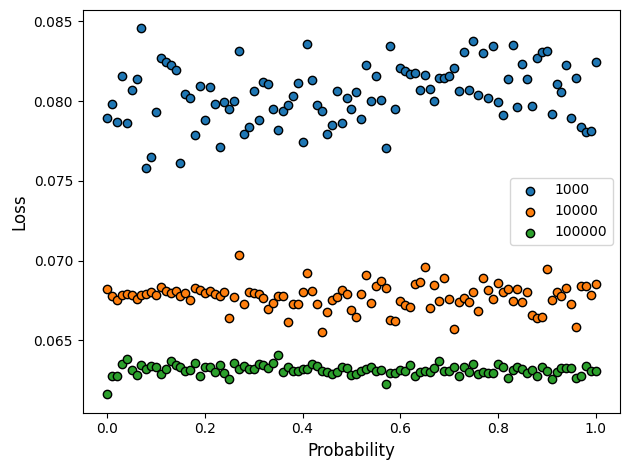

In [53]:
for i in [1000,10000,100000]:
    curve = []
    prob = []
    for file, p in zip(resultados[resultados['network_size'] == i]['file_name'], 
                       resultados[resultados['network_size'] == i]['probability']):
        arquivo = np.loadtxt('./output/' + file)
        curve.append(np.mean(arquivo[:, -1]))
        std = np.std(arquivo[:, -1])
        prob.append(p)
    prob = np.array(prob)
    curve = np.array(curve)
    curve = curve[np.argsort(prob)]
    prob = prob[np.argsort(prob)]
    #curve = curve/np.max(curve)
    plt.scatter(prob, curve, label=f"{i}", alpha=1., edgecolor='k')
    

plt.xlabel("Probability", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Ordenando e melhorando a legenda
handles, labels = plt.gca().get_legend_handles_labels()
sorted_handles_labels = sorted(zip(labels, handles), key=lambda x: float(x[0].split()[-1]))
sorted_labels, sorted_handles = zip(*sorted_handles_labels)
plt.legend(sorted_handles, sorted_labels, fontsize=10, title_fontsize=12)

# Melhorando bordas e layout
plt.tight_layout()
plt.show()


In [ ]:
for i in [1000,10000,100000]:
    curve = []
    prob = []
    for file, p in zip(resultados[resultados['network_size'] == i]['file_name'], 
                       resultados[resultados['network_size'] == i]['probability']):
        arquivo = np.loadtxt('./output/' + file)
        curve.append(np.mean(arquivo[:, -1]))
        std = np.std(arquivo[:, -1])
        prob.append(p)
    prob = np.array(prob)
    curve = np.array(curve)
    curve = curve[np.argsort(prob)]
    prob = prob[np.argsort(prob)]
    #curve = curve/np.max(curve)
    plt.scatter(prob, curve, label=f"{i}", alpha=1., edgecolor='k')
    

plt.xlabel("Probability", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Ordenando e melhorando a legenda
handles, labels = plt.gca().get_legend_handles_labels()
sorted_handles_labels = sorted(zip(labels, handles), key=lambda x: float(x[0].split()[-1]))
sorted_labels, sorted_handles = zip(*sorted_handles_labels)
plt.legend(sorted_handles, sorted_labels, fontsize=10, title_fontsize=12)

# Melhorando bordas e layout
plt.tight_layout()
plt.show()
